Name: James Fisher
Date: March 21, 2026
Course: DDS-8555 (Predictive Analytics)
Assignment: Week 4
    a. Applied Question 8 in ISLR (assigned)
    b. Non-linear Models on Kaggle Abalone Data

In [28]:
## Applied Question 8 in ISLR

# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from patsy import dmatrix, build_design_matrices
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from pygam import LinearGAM, LogisticGAM, s, f
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score

from ISLP import load_data

# Load data
Auto = load_data("Auto").copy()
Auto = Auto.dropna().reset_index(drop=True)

print(Auto.head())
print(Auto.dtypes)


    mpg  cylinders  displacement  horsepower  weight  acceleration  year  origin
0  18.0          8         307.0         130    3504          12.0    70       1
1  15.0          8         350.0         165    3693          11.5    70       1
2  18.0          8         318.0         150    3436          11.0    70       1
3  16.0          8         304.0         150    3433          12.0    70       1
4  17.0          8         302.0         140    3449          10.5    70       1
mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64
dtype: object


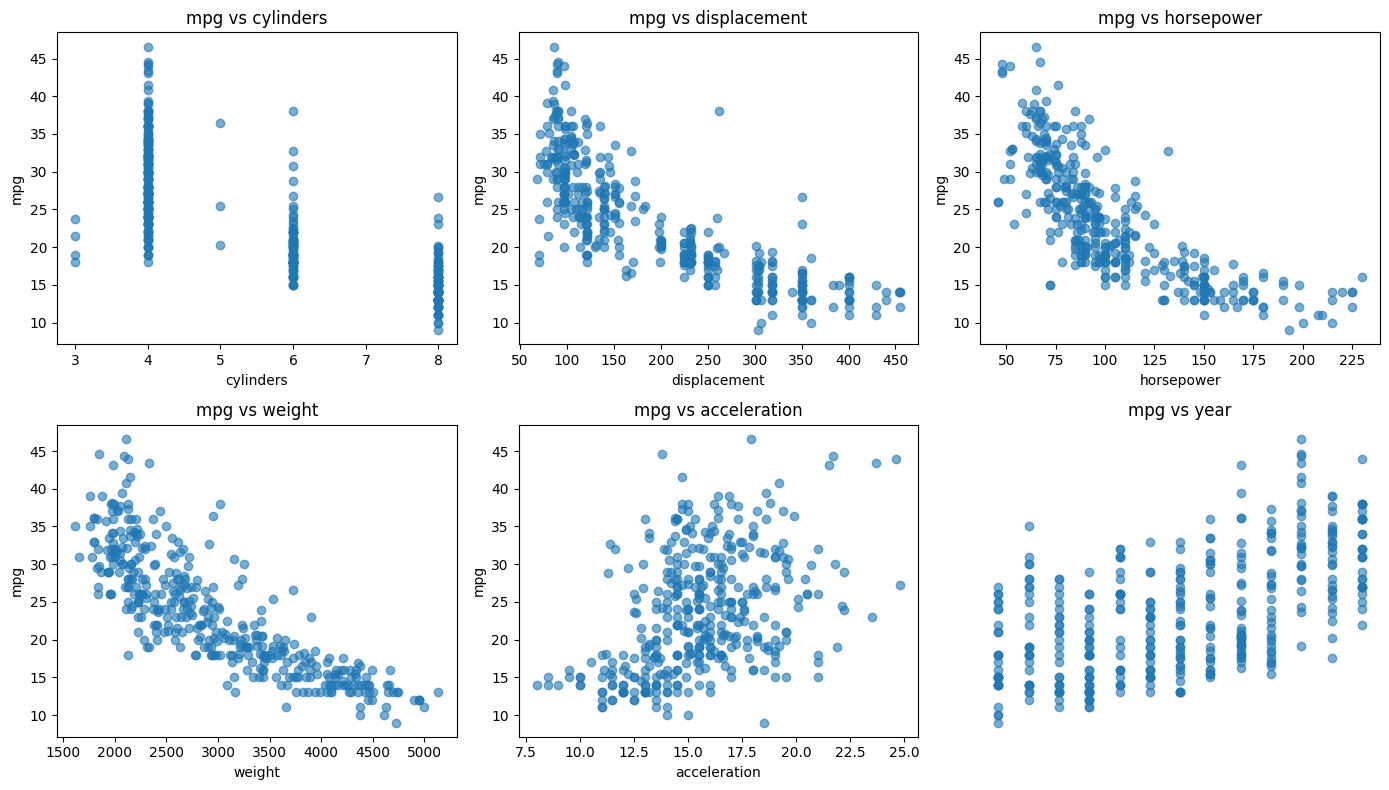

In [20]:
# Set predictors
cont_vars = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]

# Create scatterplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, var in enumerate(cont_vars):
    axes[i].scatter(Auto[var], Auto["mpg"], alpha=0.6)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("mpg")
    axes[i].set_title(f"mpg vs {var}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

c:\Users\unkno\OneDrive\Desktop\nu\DDS8555\venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


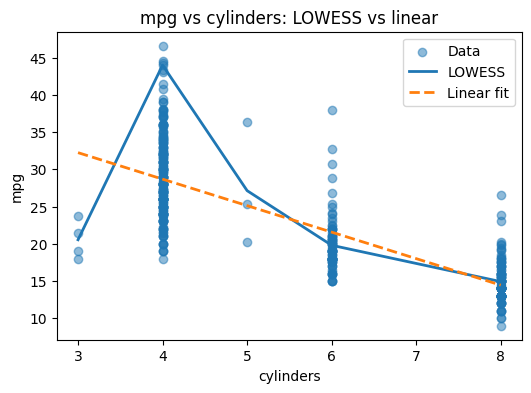

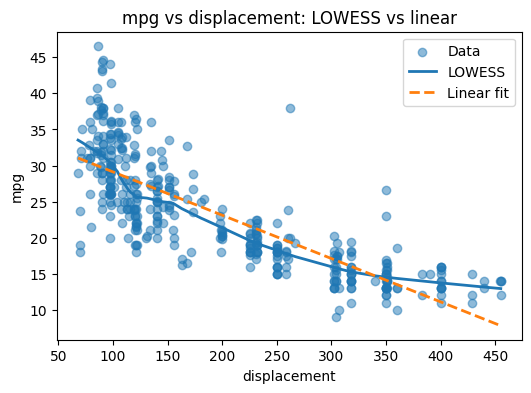

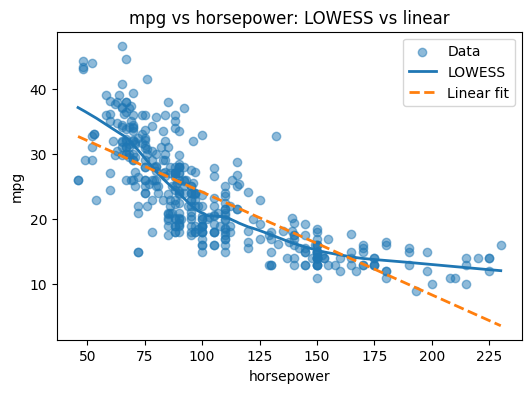

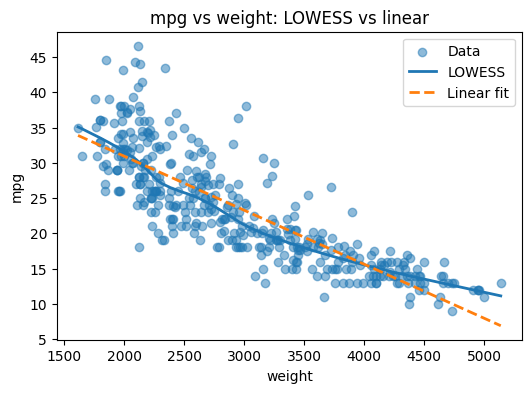

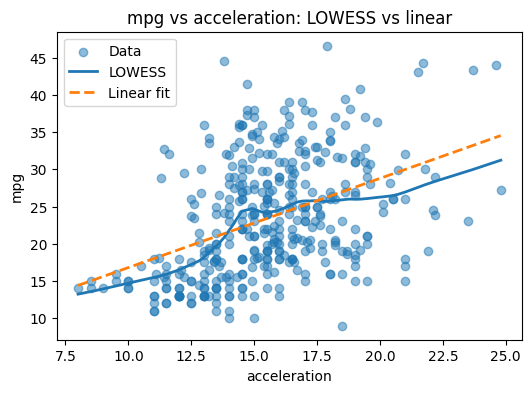

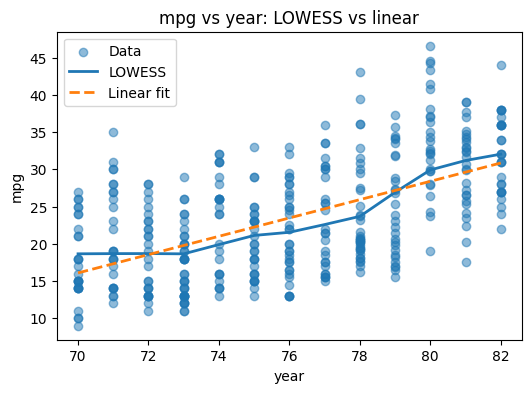

In [21]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def plot_lowess(x, y, xlab):
    order = np.argsort(x)
    x_sorted = x.iloc[order]
    y_sorted = y.iloc[order]

    low = lowess(y_sorted, x_sorted, frac=0.35, return_sorted=True)

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.5, label="Data")
    plt.plot(low[:, 0], low[:, 1], linewidth=2, label="LOWESS")
    
    # linear fit for comparison
    coef = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    yy = coef[0] * xx + coef[1]
    plt.plot(xx, yy, linestyle="--", linewidth=2, label="Linear fit")
    
    plt.xlabel(xlab)
    plt.ylabel("mpg")
    plt.title(f"mpg vs {xlab}: LOWESS vs linear")
    plt.legend()
    plt.show()

for var in cont_vars:
    plot_lowess(Auto[var], Auto["mpg"], var)

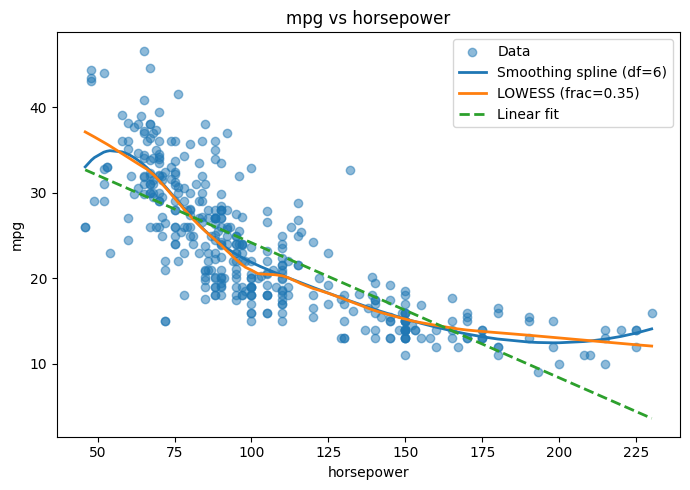

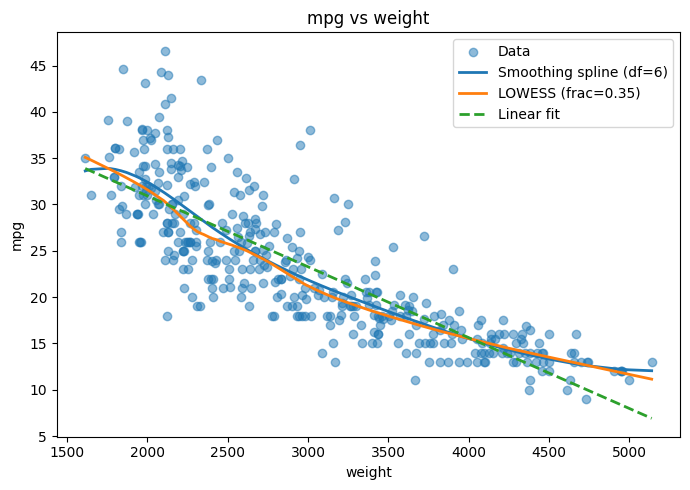

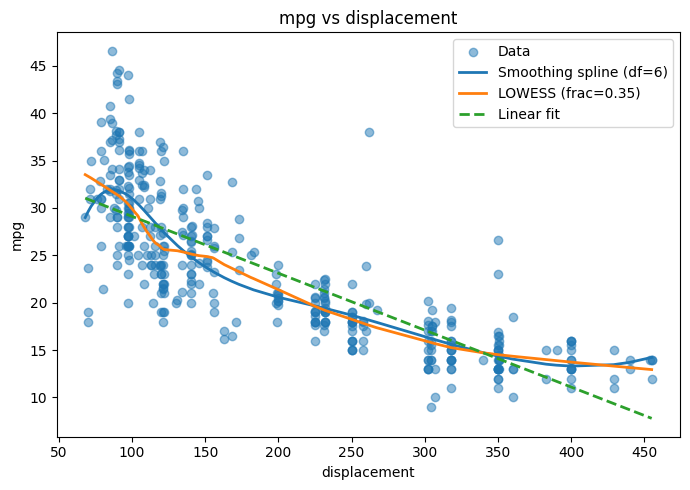

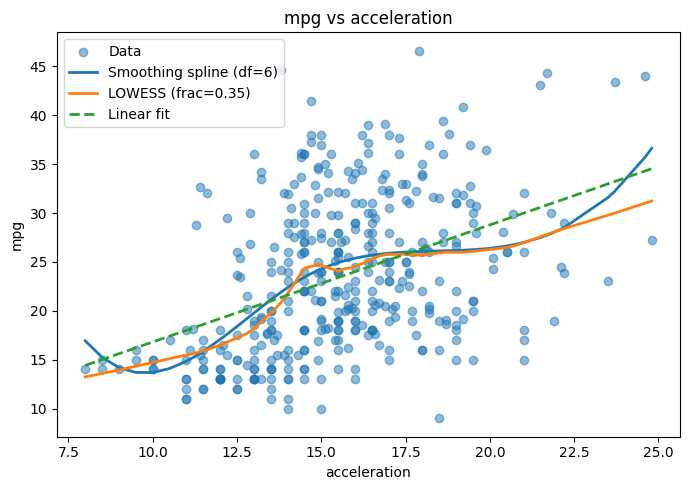

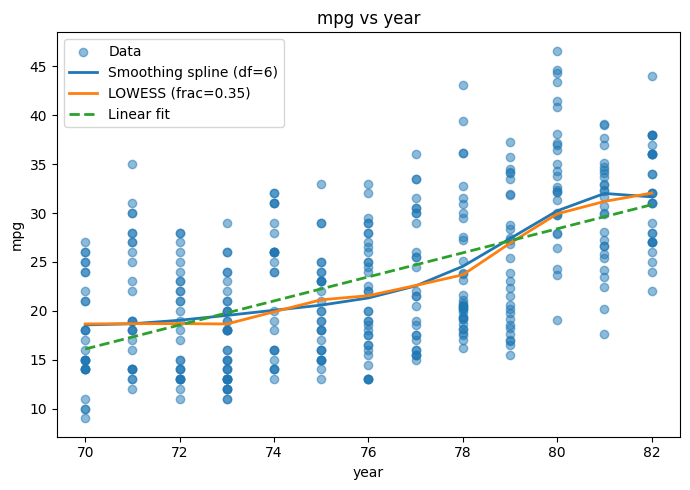

In [22]:
# Create binary response for logistic GAM
Auto["high_mpg"] = (Auto["mpg"] > Auto["mpg"].median()).astype(int)

# Continuous predictors to examine for nonlinearity
cont_vars = ["horsepower", "weight", "displacement", "acceleration", "year"]

# Optional categorical predictor
# cylinders and origin can be treated as factors if desired
Auto["cylinders"] = Auto["cylinders"].astype("category")
Auto["origin"] = Auto["origin"].astype("category")

def fit_spline(x, y, df=6):
    X_spline = dmatrix(
        f"bs(x, df={df}, degree=3, include_intercept=True)",
        {"x": x},
        return_type="dataframe"
    )
    model = sm.OLS(y, X_spline).fit()
    return model, X_spline.design_info

def predict_spline(model, design_info, x_new):
    X_new = build_design_matrices([design_info], {"x": x_new})[0]
    return model.predict(X_new)

def plot_spline_and_lowess(x, y, xlab, df=6, frac=0.35):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    spline_model, design_info = fit_spline(x, y, df=df)
    yhat_spline = predict_spline(spline_model, design_info, x_sorted)

    low = lowess(y_sorted, x_sorted, frac=frac, return_sorted=True)

    coef = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    yy = coef[0] * xx + coef[1]

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.5, label="Data")
    plt.plot(x_sorted, yhat_spline, linewidth=2, label=f"Smoothing spline (df={df})")
    plt.plot(low[:, 0], low[:, 1], linewidth=2, label=f"LOWESS (frac={frac})")
    plt.plot(xx, yy, linestyle="--", linewidth=2, label="Linear fit")
    plt.xlabel(xlab)
    plt.ylabel("mpg")
    plt.title(f"mpg vs {xlab}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for var in cont_vars:
    plot_spline_and_lowess(Auto[var], Auto["mpg"], var, df=6, frac=0.35)

In [23]:
# Comparison table using ordinary linear regression versus spline regression for each separate predictor
def linear_vs_spline_stats(x, y, df=6):
    x = np.asarray(x)
    y = np.asarray(y)

    # Linear model
    X_lin = sm.add_constant(x)
    lin_model = sm.OLS(y, X_lin).fit()

    # Spline model
    X_spline = dmatrix(
        f"bs(x, df={df}, degree=3, include_intercept=True)",
        {"x": x},
        return_type="dataframe"
    )
    spline_model = sm.OLS(y, X_spline).fit()

    return {
        "linear_R2": lin_model.rsquared,
        "spline_R2": spline_model.rsquared,
        "linear_AIC": lin_model.aic,
        "spline_AIC": spline_model.aic,
        "AIC_improvement": lin_model.aic - spline_model.aic
    }

rows = []
for var in cont_vars:
    stats = linear_vs_spline_stats(Auto[var], Auto["mpg"], df=6)
    stats["predictor"] = var
    rows.append(stats)

spline_summary = pd.DataFrame(rows)[
    ["predictor", "linear_R2", "spline_R2", "linear_AIC", "spline_AIC", "AIC_improvement"]
]

# Increase width of print output
pd.set_option("display.width", 1000)

# Display summary table with all columns on one line
print(spline_summary.sort_values("AIC_improvement", ascending=False))

      predictor  linear_R2  spline_R2   linear_AIC   spline_AIC  AIC_improvement
0    horsepower   0.605948   0.701715  2361.323658  2260.178011       101.145647
2  displacement   0.648229   0.701556  2316.830494  2260.386718        56.443776
1        weight   0.692630   0.716983  2263.938549  2239.582004        24.356544
4          year   0.337028   0.377717  2565.261976  2548.433447        16.828530
3  acceleration   0.179207   0.216595  2648.968812  2638.693126        10.275686


In [29]:
# Ensure fresh load of data for GAMs
Auto = load_data("Auto").dropna().reset_index(drop=True)

# Continuous response for Linear GAM
y = Auto["mpg"].values

# Binary response for Logistic GAM
Auto["high_mpg"] = (Auto["mpg"] > Auto["mpg"].median()).astype(int)
y_bin = Auto["high_mpg"].values

# Predictors
# Treat cylinders and origin as categorical for GAM purposes
feature_cols = ["horsepower", "displacement", "weight", "acceleration", "year", "cylinders", "origin"]
X = Auto[feature_cols].copy()

X["cylinders"] = X["cylinders"].astype("category")
X["origin"] = X["origin"].astype("category")

# pyGAM needs numeric arrays, so convert categories to codes
X_gam = pd.DataFrame({
    "horsepower": X["horsepower"],
    "displacement": X["displacement"],
    "weight": X["weight"],
    "acceleration": X["acceleration"],
    "year": X["year"],
    "cylinders": X["cylinders"].cat.codes,
    "origin": X["origin"].cat.codes
})

X_mat = X_gam.values

# Fit Linear GAM
linear_gam = LinearGAM(
    s(0) +   # horsepower
    s(1) +   # displacement
    s(2) +   # weight
    s(3) +   # acceleration
    s(4) +   # year
    f(5) +   # cylinders
    f(6)     # origin
).fit(X_mat, y)

print(linear_gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      57.885
Link Function:                     IdentityLink Log Likelihood:                                  -889.8177
Number of Samples:                          392 AIC:                                             1897.4054
                                                AICc:                                            1918.6409
                                                GCV:                                                8.6114
                                                Scale:                                              2.5215
                                                Pseudo R-Squared:                                   0.9108
Feature Function                  Lam

C:\Users\unkno\AppData\Local\Temp\ipykernel_48776\1581295013.py:43: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(linear_gam.summary())


Now, on to the Abalone Dataset. The purposes here are to create two additional models for the Kaggle Abalone dataset challenge, one using spline smoothing and the second a generalized additive model. Interpretation and investigation of assumptions and outputs of each regression model is provided in the included document. 

In [ ]:
###################################
## KAGGLE COMPETITION CODE BELOW ##
####################################

In [36]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

from pygam import LinearGAM, s, f

# Load Data
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission template shape:", sample_sub.shape)

print("\nTrain columns:")
print(train.columns.tolist())

Train shape: (90615, 10)
Test shape: (60411, 9)
Submission template shape: (60411, 2)

Train columns:
['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings']


In [37]:
## Preprocessing
# Set target
target = "Rings"

# Features
id_col = "id"
cat_cols = ["Sex"]
num_cols = [c for c in train.columns if c not in [id_col, target] + cat_cols]

# Treat zero height as missing, then impute later
for df in [train, test]:
    df.loc[df["Height"] == 0, "Height"] = np.nan

# log target for RMSLE-aligned modeling
train["log_rings"] = np.log1p(train[target])

# train/validation split for diagnostic plots
train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train = train_df.drop(columns=[target, "log_rings"])
y_train = train_df["log_rings"].copy()

X_valid = valid_df.drop(columns=[target, "log_rings"])
y_valid = valid_df["log_rings"].copy()

X_full = train.drop(columns=[target, "log_rings"])
y_full = train["log_rings"].copy()

X_test = test.copy()


In [56]:
# Helper functions (to save time later)
def rmsle_from_logs(y_true_log, y_pred_log):
    """
    RMSE on log1p scale, aligned to RMSLE if predictions are inverse-transformed.
    """
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

def rmsle_original_scale(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def summarize_predictions(y_true_log, y_pred_log, model_name="model"):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)

    out = {
        "model": model_name,
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSLE": rmsle_original_scale(y_true, y_pred)
    }
    return out

def plot_target_distribution(df, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df["Rings"], bins=30, kde=True, ax=axes[0])
    axes[0].set_title("Distribution of Rings")
    axes[0].set_xlabel("Rings")

    sns.histplot(np.log1p(df["Rings"]), bins=30, kde=True, ax=axes[1])
    axes[1].set_title("Distribution of log1p(Rings)")
    axes[1].set_xlabel("log1p(Rings)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

def plot_numeric_relationships(df, numeric_columns, save_path):
    n = len(numeric_columns)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, numeric_columns):
        sns.scatterplot(data=df.sample(min(12000, len(df)), random_state=RANDOM_STATE),
                        x=col, y="Rings", alpha=0.25, s=18, ax=ax)
        sns.regplot(data=df.sample(min(12000, len(df)), random_state=RANDOM_STATE),
                    x=col, y="Rings",
                    lowess=True,
                    scatter=False,
                    line_kws={"linewidth": 2},
                    ax=ax)
        ax.set_title(f"Rings vs {col}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

def make_submission(ids, preds_original_scale, template_df, save_path):
    sub = template_df.copy()
    sub["id"] = ids
    sub["Rings"] = np.clip(preds_original_scale, 0, None)
    sub["Rings"] = sub["Rings"].round().astype(int)
    sub.to_csv(save_path, index=False)
    return sub

In [57]:
# Spline smoothing model
numeric_spline_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("spline", SplineTransformer(
            n_knots=N_SPLINES,
            degree=SPLINE_DEGREE,
            include_bias=False
        ))
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

spline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_spline_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

alphas = np.logspace(-4, 4, 25)

spline_model = Pipeline(
    steps=[
        ("preprocess", spline_preprocessor),
        ("ridge", RidgeCV(alphas=alphas))
    ]
)

In [58]:
# Preprocessing for GAM
sex_map = {"F": 0, "I": 1, "M": 2}

def prepare_gam_frame(df):
    out = df.copy()
    out["Height"] = out["Height"].fillna(out["Height"].median())
    out["Sex_code"] = out["Sex"].map(sex_map).astype(int)
    cols = ["Length", "Diameter", "Height",
            "Whole weight", "Whole weight.1", "Whole weight.2",
            "Shell weight", "Sex_code"]
    return out[cols]

X_train_gam = prepare_gam_frame(train_df.drop(columns=[target, "log_rings"]))
X_valid_gam = prepare_gam_frame(valid_df.drop(columns=[target, "log_rings"]))
X_full_gam = prepare_gam_frame(train.drop(columns=[target, "log_rings"]))
X_test_gam = prepare_gam_frame(test)

# smooth terms for numeric features + factor term for Sex_code
gam = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + f(7)
)

In [59]:
# Cross-validation setup
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

# Spline model CV
for fold, (tr_idx, va_idx) in enumerate(kf.split(train), start=1):
    tr = train.iloc[tr_idx].copy()
    va = train.iloc[va_idx].copy()

    X_tr = tr.drop(columns=[target, "log_rings"])
    y_tr = tr["log_rings"].copy()

    X_va = va.drop(columns=[target, "log_rings"])
    y_va = va["log_rings"].copy()

    model = clone(spline_model)
    model.fit(X_tr, y_tr)
    pred_va = model.predict(X_va)

    cv_rows.append({
        "model": "Spline smoothing",
        "fold": fold,
        "RMSE_log": np.sqrt(mean_squared_error(y_va, pred_va)),
        "MAE_log": mean_absolute_error(y_va, pred_va),
        "R2_log": r2_score(y_va, pred_va),
        "RMSLE": rmsle_original_scale(np.expm1(y_va), np.expm1(pred_va))
    })

# GAM CV
for fold, (tr_idx, va_idx) in enumerate(kf.split(train), start=1):
    tr = train.iloc[tr_idx].copy()
    va = train.iloc[va_idx].copy()

    X_tr = prepare_gam_frame(tr.drop(columns=[target, "log_rings"])).values
    y_tr = tr["log_rings"].values

    X_va = prepare_gam_frame(va.drop(columns=[target, "log_rings"])).values
    y_va = va["log_rings"].values

    model = LinearGAM(
        s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + f(7)
    )
    model.gridsearch(X_tr, y_tr, progress=False)
    pred_va = model.predict(X_va)

    cv_rows.append({
        "model": "GAM",
        "fold": fold,
        "RMSE_log": np.sqrt(mean_squared_error(y_va, pred_va)),
        "MAE_log": mean_absolute_error(y_va, pred_va),
        "R2_log": r2_score(y_va, pred_va),
        "RMSLE": rmsle_original_scale(np.expm1(y_va), np.expm1(pred_va))
    })

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results
    .groupby("model")[["RMSE_log", "MAE_log", "R2_log", "RMSLE"]]
    .agg(["mean", "std"])
    .round(5)
)

print("\nCross-validated model comparison:")
print(cv_summary)

cv_results.to_csv("cv_fold_results.csv", index=False)
cv_summary.to_csv("cv_model_comparison.csv")



Cross-validated model comparison:
                 RMSE_log           MAE_log            R2_log            RMSLE         
                     mean      std     mean      std     mean      std    mean      std
model                                                                                  
GAM                0.1545  0.00118  0.11422  0.00065  0.70714  0.00500  0.1545  0.00118
Spline smoothing   0.1548  0.00120  0.11445  0.00074  0.70600  0.00484  0.1548  0.00120


In [60]:
# Fit on split (for diagnostic plots)
# Spline model
spline_model.fit(X_train, y_train)
spline_valid_pred_log = spline_model.predict(X_valid)

# GAM with lambda tuning
gam.gridsearch(X_train_gam.values, y_train.values, progress=False)
gam_valid_pred_log = gam.predict(X_valid_gam.values)

spline_metrics = summarize_predictions(y_valid, spline_valid_pred_log, "Spline smoothing")
gam_metrics = summarize_predictions(y_valid, gam_valid_pred_log, "GAM")

holdout_metrics = pd.DataFrame([spline_metrics, gam_metrics]).round(5)
print("\nHoldout validation metrics:")
print(holdout_metrics)
holdout_metrics.to_csv("holdout_metrics.csv", index=False)


Holdout validation metrics:
              model  RMSE_log  MAE_log   R2_log    RMSLE
0  Spline smoothing   0.15603  0.11537  0.70552  0.15603
1               GAM   0.15552  0.11497  0.70743  0.15552


In [61]:
# Create interpretation tables
# Top spline basis coefficients
feature_names = spline_model.named_steps["preprocess"].get_feature_names_out()
coefs = np.ravel(spline_model.named_steps["ridge"].coef_)   # flatten to 1D

print("n feature names:", len(feature_names))
print("coef shape:", coefs.shape)

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)

print("\nTop spline coefficients:")
print(coef_table.head(20))
coef_table.head(50).to_csv("spline_coefficients_top.csv", index=False)

n feature names: 65
coef shape: (65,)

Top spline coefficients:
                     feature  coefficient  abs_coefficient
54    num__Shell weight_sp_0    -1.486037         1.486037
27    num__Whole weight_sp_0    -1.036129         1.036129
0           num__Length_sp_0     0.992000         0.992000
17        num__Diameter_sp_8     0.841263         0.841263
14        num__Diameter_sp_5     0.815046         0.815046
10        num__Diameter_sp_1     0.786574         0.786574
61    num__Shell weight_sp_7     0.774824         0.774824
13        num__Diameter_sp_4     0.761933         0.761933
12        num__Diameter_sp_3     0.760873         0.760873
16        num__Diameter_sp_7     0.758363         0.758363
60    num__Shell weight_sp_6     0.710933         0.710933
15        num__Diameter_sp_6     0.698868         0.698868
11        num__Diameter_sp_2     0.698203         0.698203
37  num__Whole weight.1_sp_1     0.667266         0.667266
3           num__Length_sp_3     0.651712         0

In [ ]:
# Test against test set for accuracy metrics


In [62]:
# GAM term summary
edof_per_coef = gam.statistics_["edof_per_coef"]
coef_slices = gam.terms.get_coef_indices()

term_names = [
    "Length", "Diameter", "Height",
    "Whole weight", "Whole weight.1", "Whole weight.2",
    "Shell weight", "Sex"
]

term_edof = []
for idxs in coef_slices[:-1]:
    idxs = np.atleast_1d(idxs)
    term_edof.append(edof_per_coef[idxs].sum())

min_len = min(len(term_names), len(term_edof))

gam_term_summary = pd.DataFrame({
    "term": term_names[:min_len],
    "EDoF": term_edof[:min_len]
}).sort_values("EDoF", ascending=False)

print("\nGAM term summary:")
print(gam_term_summary.round(3))
gam_term_summary.to_csv("gam_term_summary.csv", index=False)


GAM term summary:
             term   EDoF
7             Sex  0.974
6    Shell weight  0.960
5  Whole weight.2  0.943
4  Whole weight.1  0.875
3    Whole weight  0.788
2          Height  0.731
0          Length  0.639
1        Diameter  0.515


In [63]:
# Create visualizations to understand distributions
plot_target_distribution(train, "fig_target_distribution.png")

# Raw feature relationships
plot_numeric_relationships(train, num_cols, "fig_numeric_relationships.png")

# Residual diagnostics on validation set
def plot_residuals(y_true_log, y_pred_log, model_name, save_path):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    resid = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.scatterplot(x=y_pred, y=resid, alpha=0.4, ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_xlabel("Predicted Rings")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{model_name}: Residuals vs Predicted")

    sns.histplot(resid, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"{model_name}: Residual Distribution")
    axes[1].set_xlabel("Residual")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

plot_residuals(y_valid, spline_valid_pred_log, "Spline smoothing", "fig_residuals_spline.png")
plot_residuals(y_valid, gam_valid_pred_log, "GAM", "fig_residuals_gam.png")

# Partial dependence for spline model
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    spline_model,
    X_valid,
    features=num_cols,
    kind="average",
    grid_resolution=40,
    ax=ax
)
plt.tight_layout()
plt.savefig("fig_pdp_spline.png", dpi=200, bbox_inches="tight")
plt.close()

# GAM smooth plots
n_terms = len(term_names)
ncols = 3
nrows = int(np.ceil(n_terms / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, name in enumerate(term_names):
    ax = axes[i]
    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)
    confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, linewidth=2)
    ax.plot(XX[:, i], confi[0], linestyle="--", linewidth=1)
    ax.plot(XX[:, i], confi[1], linestyle="--", linewidth=1)
    ax.set_title(f"GAM smooth: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("Effect on log1p(Rings)")

for ax in axes[n_terms:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("fig_gam_smooths.png", dpi=200, bbox_inches="tight")
plt.close()

# Actual vs predicted
def plot_actual_vs_pred(y_true_log, y_pred_log, model_name, save_path):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)

    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.35)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--", color="black")
    plt.xlabel("Actual Rings")
    plt.ylabel("Predicted Rings")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

plot_actual_vs_pred(y_valid, spline_valid_pred_log, "Spline smoothing", "fig_actual_vs_pred_spline.png")
plot_actual_vs_pred(y_valid, gam_valid_pred_log, "GAM", "fig_actual_vs_pred_gam.png")

In [64]:
# Fit final models on all training data
# Final spline model
spline_model.fit(X_full, y_full)
spline_test_pred_log = spline_model.predict(X_test)
spline_test_pred = np.clip(np.expm1(spline_test_pred_log), 0, None)

# Final GAM
gam_final = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + f(7)
)
gam_final.gridsearch(X_full_gam.values, y_full.values, progress=False)
gam_test_pred_log = gam_final.predict(X_test_gam.values)
gam_test_pred = np.clip(np.expm1(gam_test_pred_log), 0, None)

In [65]:
# Export Kaggle submission files
sub_spline = make_submission(
    ids=test["id"].values,
    preds_original_scale=spline_test_pred,
    template_df=sample_sub,
    save_path="submission_spline.csv"
)

sub_gam = make_submission(
    ids=test["id"].values,
    preds_original_scale=gam_test_pred,
    template_df=sample_sub,
    save_path="submission_gam.csv"
)

print("Saved.")

Saved.
